In [1]:
import sys

print(sys.executable)

e:\Guvi hcl file manager\GUVI_3_project\venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

print("Environment is working!")

Pandas: 3.0.5
NumPy: 2.5.2
Environment is working!


In [3]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
file_path = r"E:\Guvi hcl file manager\GUVI_my_third_project\data\raw\india_housing_prices.csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
print(df.head())

   ID        State      City      Locality      Property_Type  BHK  \
0   1   Tamil Nadu   Chennai   Locality_84          Apartment    1   
1   2  Maharashtra      Pune  Locality_490  Independent House    3   
2   3       Punjab  Ludhiana  Locality_167          Apartment    2   
3   4    Rajasthan   Jodhpur  Locality_393  Independent House    2   
4   5    Rajasthan    Jaipur  Locality_466              Villa    4   

   Size_in_SqFt  Price_in_Lakhs  Price_per_SqFt  Year_Built Furnished_Status  \
0          4740          489.76            0.10        1990        Furnished   
1          2364          195.52            0.08        2008      Unfurnished   
2          3642          183.79            0.05        1997   Semi-furnished   
3          2741          300.29            0.11        1991        Furnished   
4          4823          182.90            0.04        2002   Semi-furnished   

   Floor_No  Total_Floors  Age_of_Property  Nearby_Schools  Nearby_Hospitals  \
0        22       

In [6]:
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

Rows    : 250000
Columns : 23


In [7]:
print(df.columns.tolist())

['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']


In [8]:
print(df.dtypes)

ID                                  int64
State                                 str
City                                  str
Locality                              str
Property_Type                         str
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                      str
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility        str
Parking_Space                         str
Security                              str
Amenities                             str
Facing                                str
Owner_Type                            str
Availability_Status                   str
dtype: object


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  str    
 2   City                            250000 non-null  str    
 3   Locality                        250000 non-null  str    
 4   Property_Type                   250000 non-null  str    
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  str    
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors               

In [11]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
if duplicate_count > 0:
   df = df.drop_duplicates().reset_index(drop=True)
   print("Duplicate rows removed.")
else:
   print("No duplicate rows found.")

No duplicate rows found.


In [14]:
missing_values = df.isnull().sum()

In [15]:
missing_percentage = (missing_values / len(df)) * 100
missing_table = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
})
print(missing_table[missing_table["Missing_Count"] > 0])

Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []


In [17]:
df.columns = (
    df.columns
   .str.strip()
   .str.replace(" ", "_")
)
print(df.columns.tolist())

['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']


In [18]:
categorical_columns = df.select_dtypes(include=["object"]).columns
for col in categorical_columns:
   df[col] = df[col].astype("string").str.strip()
print("\nCategorical columns cleaned.")


Categorical columns cleaned.


C:\Users\Jeshmitha\AppData\Local\Temp\ipykernel_13720\2148667822.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [19]:
numerical_columns = [
   "ID",
   "BHK",
   "Size_in_SqFt",
   "Price_in_Lakhs",
   "Price_per_SqFt",
   "Year_Built",
   "Floor_No",
   "Total_Floors",
   "Age_of_Property",
   "Nearby_Schools",
   "Nearby_Hospitals",
   "Public_Transport_Accessibility",
   "Parking_Space"
]
for col in numerical_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)
print("\nMissing numerical values handled using median.")


Missing numerical values handled using median.


In [21]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns
for col in categorical_cols:
   if df[col].isnull().sum() > 0:
       mode_value = df[col].mode()
 
       if len(mode_value) > 0:
        df[col] = df[col].fillna(mode_value[0])
       else:
           df[col] = df[col].fillna("Unknown")
print("Missing categorical values handled using mode.")

Missing categorical values handled using mode.


In [22]:
remaining_missing = df.isnull().sum()
print(remaining_missing[remaining_missing > 0])
if remaining_missing.sum() == 0:
    print("No missing values remaining.")

Public_Transport_Accessibility    250000
Parking_Space                     250000
dtype: int64


In [23]:
print("\n========== FINAL DATASET INFORMATION ==========")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])
print("\n========== FINAL DATA TYPES ==========")
print(df.dtypes)
print("\n========== FINAL 5 ROWS ==========")
print(df.head())


========== FINAL DATASET INFORMATION ==========
Rows    : 250000
Columns : 23

========== FINAL DATA TYPES ==========
ID                                  int64
State                              string
City                               string
Locality                           string
Property_Type                      string
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   string
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility    Float64
Parking_Space                     Float64
Security                           string
Amenities                          string
Facing                             string

In [28]:
cleaned_file_path = (r"E:\Guvi hcl file manager\GUVI_3_project\data\processed\cleaned_housing_prices.csv"
)

In [29]:
import os
os.makedirs(os.path.dirname(cleaned_file_path), exist_ok=True)
df.to_csv(cleaned_file_path, index=False)
print("\nCleaned dataset saved successfully!")
print(cleaned_file_path)


Cleaned dataset saved successfully!
E:\Guvi hcl file manager\GUVI_3_project\data\processed\cleaned_housing_prices.csv


In [30]:
# STEP 2: FEATURE ENGINEERING
df = df.copy()

In [31]:
# 1. PRICE PER SQFT
df["Calculated_Price_per_SqFt"] = (
     df["Price_in_Lakhs"] * 100000
) / df["Size_in_SqFt"]
print("Price per SqFt feature created.")

Price per SqFt feature created.


In [32]:
# 2. PROPERTY AGE
CURRENT_YEAR = 2026
df["Calculated_Age_of_Property"] = (
    CURRENT_YEAR- df["Year_Built"]
)
print("Property age feature created.")

Property age feature created.


In [33]:
# 3. AMENITY DENSITY SCORE
amenity_columns = [
    "Nearby_Schools",
    "Nearby_Hospitals",
    "Parking_Space"
]
existing_amenity_columns = [
     col for col in amenity_columns if col in df.columns
]
df["Amenity_Density_Score"] = (
    df[existing_amenity_columns]
    .fillna(0)
    .sum(axis=1)
)
print("Amenity Density Score created.")

Amenity Density Score created.


In [34]:
# 4. TOTAL AMENITIES COUNT
if "Amenities" in df.columns:
    df["Amenities_Count"] = (
       df["Amenities"]
       .fillna("None")
       .astype(str)
       .apply(
            lambda x: 0
            if x.lower() in ["none", "nan", ""]
            else len(x.split(","))
        )
   )
else:
   df["Amenities_Count"] = 0

In [ ]:
# 5. FLOOR RATIO
if "Floor_No" in df.columns and "Total_Floors" in df.columns:
    df["Floor_Ratio"] = (
        df["Floor_No"] / df["Total_Floors"].replace(0, np.nan)
    )
    df["Floor_Ratio"] = df["Floor_Ratio"].fillna(0)

In [39]:
# 6. PROPERTY DEVELOPMENT / INFRASTRUCTURE SCORE

score_columns = []

infrastructure_columns = [
    "Nearby_Schools",
    "Nearby_Hospitals",
    "Public_Transport_Accessibility"
]

for col in infrastructure_columns:

    if col in df.columns:

        # Convert column to numeric
        df[col] = pd.to_numeric(df[col], errors="coerce")

        # Fill missing values with median
        df[col] = df[col].fillna(df[col].median())

        min_value = df[col].min()
        max_value = df[col].max()

        # Avoid division by zero
        if pd.notna(min_value) and pd.notna(max_value) and max_value != min_value:

            normalized_col = f"{col}_Normalized"

            df[normalized_col] = (
                (df[col] - min_value)
                / (max_value - min_value)
            )

            score_columns.append(normalized_col)


# Calculate Infrastructure Score
if len(score_columns) > 0:

    df["Infrastructure_Score"] = df[score_columns].mean(axis=1)

else:

    df["Infrastructure_Score"] = 0


print("Infrastructure Score created successfully!")

print("\nScore columns:")
print(score_columns)

print("\nInfrastructure Score summary:")
print(df["Infrastructure_Score"].describe())

Infrastructure Score created successfully!

Score columns:
['Nearby_Schools_Normalized', 'Nearby_Hospitals_Normalized']

Infrastructure Score summary:
count    250000.000000
mean          0.499882
std           0.225647
min           0.000000
25%           0.333333
50%           0.500000
75%           0.666667
max           1.000000
Name: Infrastructure_Score, dtype: float64


In [44]:
# 7. INVESTMENT POTENTIAL SCORE

# -----------------------------------------
# Clean required columns
# -----------------------------------------

# Infrastructure Score
df["Infrastructure_Score"] = pd.to_numeric(
    df["Infrastructure_Score"],
    errors="coerce"
).fillna(0)


# Amenities Count
df["Amenities_Count"] = pd.to_numeric(
    df["Amenities_Count"],
    errors="coerce"
).fillna(0)


# Parking Space
df["Parking_Space"] = pd.to_numeric(
    df["Parking_Space"],
    errors="coerce"
).fillna(0)


# -----------------------------------------
# Find maximum values safely
# -----------------------------------------

max_amenities = df["Amenities_Count"].max()

max_parking = df["Parking_Space"].max()


# Avoid division by zero
if pd.isna(max_amenities) or max_amenities == 0:
    max_amenities = 1

if pd.isna(max_parking) or max_parking == 0:
    max_parking = 1


# -----------------------------------------
# Calculate Investment Potential Score
# -----------------------------------------

df["Investment_Potential_Score"] = (
    
    df["Infrastructure_Score"] * 0.5
    
    + (df["Amenities_Count"] / max_amenities) * 0.3
    
    + (df["Parking_Space"] / max_parking) * 0.2
)


# -----------------------------------------
# Display results
# -----------------------------------------

print("Investment Potential Score created successfully!")

print("\nScore Summary:")
print(df["Investment_Potential_Score"].describe())

print("\nFirst 5 rows:")
print(
    df[
        [
            "Infrastructure_Score",
            "Amenities_Count",
            "Parking_Space",
            "Investment_Potential_Score"
        ]
    ].head()
)

Investment Potential Score created successfully!

Score Summary:
count    250000.0
mean     0.429958
std      0.141074
min          0.06
25%      0.337778
50%          0.43
75%      0.522222
max           0.8
Name: Investment_Potential_Score, dtype: Float64

First 5 rows:
   Infrastructure_Score  Amenities_Count  Parking_Space  \
0              0.611111                5            0.0   
1              0.388889                5            0.0   
2              0.833333                4            0.0   
3              0.555556                5            0.0   
4              0.611111                5            0.0   

   Investment_Potential_Score  
0                    0.605556  
1                    0.494444  
2                    0.656667  
3                    0.577778  
4                    0.605556  


In [45]:
#8. PRICE CATEGORY
df["Price_Range"] = pd.cut(
    df["Price_in_Lakhs"],
    bins=[0, 50, 100, 200, 500, np.inf],
    labels=[
        "Below 50L",
        "50L-1Cr",
        "1Cr-2Cr",
        "2Cr-5Cr",
        "Above 5Cr"
   ]
)

In [46]:
# 9. SIZE CATEGORY
df["Size_Category"] = pd.cut(
    df["Size_in_SqFt"],
    bins=[0, 500, 1000, 1500, 2500, np.inf],
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large",
        "Luxury"
    ]
)


In [47]:
# 10. BHK CATEGORY
df["BHK_Category"] = pd.cut(
    df["BHK"],
    bins=[0, 1, 2, 3, 4, np.inf],
    labels=[
        "1 BHK",
        "2 BHK",
        "3 BHK",
        "4 BHK",
        "5+ BHK"
    ]
)


In [48]:
# 11. GOOD INVESTMENT TARGET
investment_threshold = df[
     "Investment_Potential_Score"
].median()

df["Good_Investment"] = (
    df["Investment_Potential_Score"]
    >= investment_threshold
).astype(int)

In [49]:
# 12. FUTURE PRICE AFTER 5 YEARS
annual_appreciation_rate = 0.08

df["Future_Price_5Y"] = (
    df["Price_in_Lakhs"]
    * (1 + annual_appreciation_rate) ** 5
)


In [50]:
# 13. CHECK NEW FEATURES
new_features = [
    "Calculated_Price_per_SqFt",
    "Calculated_Age_of_Property",
    "Amenity_Density_Score",
    "Amenities_Count",
    "Floor_Ratio",
    "Infrastructure_Score",
    "Investment_Potential_Score",
    "Price_Range",
    "Size_Category",
    "BHK_Category",
    "Good_Investment",
    "Future_Price_5Y"
]
print("\n========== NEW FEATURES ==========")
for col in new_features:
    if col in df.columns:
       print(col)


========== NEW FEATURES ==========
Calculated_Price_per_SqFt
Calculated_Age_of_Property
Amenity_Density_Score
Amenities_Count
Floor_Ratio
Infrastructure_Score
Investment_Potential_Score
Price_Range
Size_Category
BHK_Category
Good_Investment
Future_Price_5Y


In [51]:
# 14. DISPLAY FEATURE ENGINEERED DATA
print("\n========== SAMPLE DATA ==========")
display(
    df[
        [
            "Price_in_Lakhs",
            "Size_in_SqFt",
            "Calculated_Price_per_SqFt",
            "Year_Built",
            "Calculated_Age_of_Property",
            "Amenities_Count",
            "Infrastructure_Score",
            "Investment_Potential_Score",
            "Good_Investment",
            "Future_Price_5Y"
       ]
    ].head(10)
)


========== SAMPLE DATA ==========


,Price_in_Lakhs,Size_in_SqFt,Calculated_Price_per_SqFt,Year_Built,Calculated_Age_of_Property,Amenities_Count,Infrastructure_Score,Investment_Potential_Score,Good_Investment,Future_Price_5Y
0,489.76,4740,10332.489451,1990,36,5,0.611111,0.605556,1,719.618119
1,195.52,2364,8270.727580,2008,18,5,0.388889,0.494444,1,287.283026
2,183.79,3642,5046.403075,1997,29,4,0.833333,0.656667,1,270.047807
3,300.29,2741,10955.490697,1991,35,5,0.555556,0.577778,1,441.224528
4,182.90,4823,3792.245490,2002,24,5,0.611111,0.605556,1,268.740105
5,135.28,3500,3865.142857,2020,6,2,0.666667,0.453333,1,198.770702
6,318.12,4826,6591.794447,2016,10,3,0.388889,0.374444,0,467.422648
7,141.39,4252,3325.258702,2021,5,4,1.000000,0.74,1,207.748297
8,189.16,2678,7063.480209,2003,23,3,0.555556,0.457778,1,277.938099
9,187.42,1393,13454.414932,2011,15,4,0.222222,0.351111,0,275.381468


In [52]:
# 15. CHECK TARGET DISTRIBUTION

print("\n========== GOOD INVESTMENT DISTRIBUTION ==========")
print(df["Good_Investment"].value_counts()) 

print("\nPercentage:")

print(
    df["Good_Investment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


========== GOOD INVESTMENT DISTRIBUTION ==========
Good_Investment
1    127509
0    122491
Name: count, dtype: int64

Percentage:
Good_Investment
1    51.0
0    49.0
Name: proportion, dtype: float64


In [53]:
# 16. SAVE FEATURE-ENGINEERED DATASET
feature_file_path = (
    r"E:\Guvi hcl file manager\GUVI_my_third_project"
    r"\data\processed\feature_engineered_housing_prices.csv"
)

import os

os.makedirs(
    os.path.dirname(feature_file_path),
    exist_ok=True
)

df.to_csv(
    feature_file_path,
    index=False
)
print("\nFeature-engineered dataset saved successfully!")
print(feature_file_path)


Feature-engineered dataset saved successfully!
E:\Guvi hcl file manager\GUVI_my_third_project\data\processed\feature_engineered_housing_prices.csv


In [54]:
# ============================================================
# REAL ESTATE INVESTMENT ADVISOR
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# 20 EDA QUESTIONS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

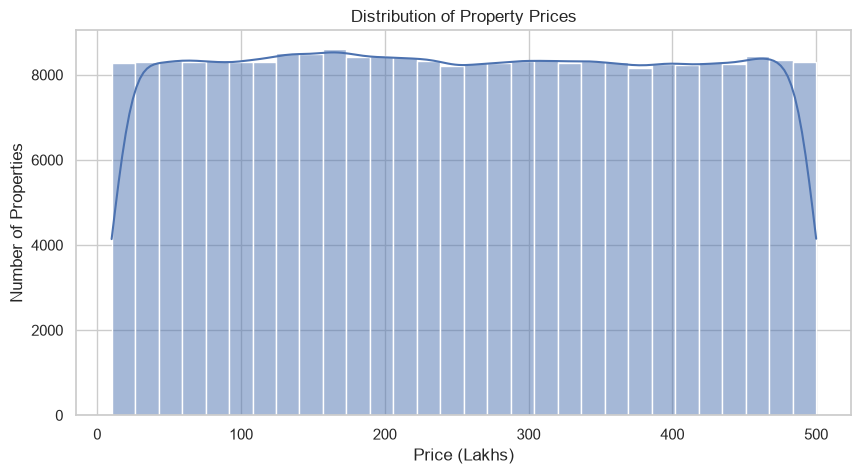

In [55]:
# ============================================================
# Q1. What is the distribution of property prices?
# ============================================================
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Price_in_Lakhs"],
    bins=30,
    kde=True
)

plt.title("Distribution of Property Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Properties")
plt.show()

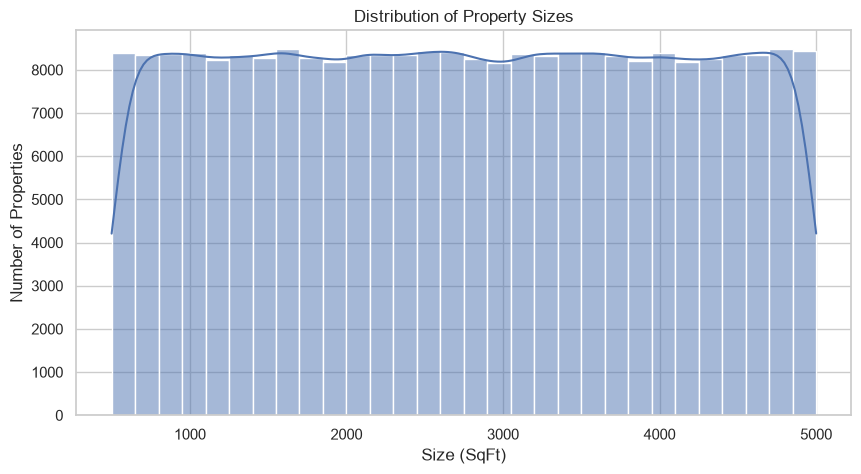

In [57]:
# ============================================================
# Q2. What is the distribution of property sizes?
# ============================================================
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Size_in_SqFt"],
    bins=30,
    kde=True
)

plt.title("Distribution of Property Sizes")
plt.xlabel("Size (SqFt)")
plt.ylabel("Number of Properties")
plt.show()

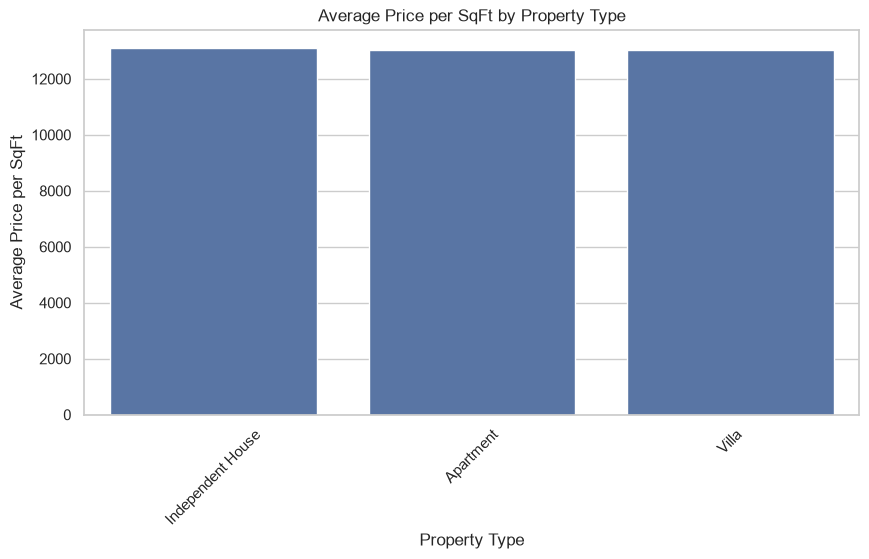

In [58]:
# ============================================================
# Q3. How does price per sq ft vary by property type?
# ============================================================
price_type = (
    df.groupby("Property_Type")["Calculated_Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
   x=price_type.index,
   y=price_type.values
)
plt.title("Average Price per SqFt by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Average Price per SqFt")
plt.xticks(rotation=45)
plt.show()

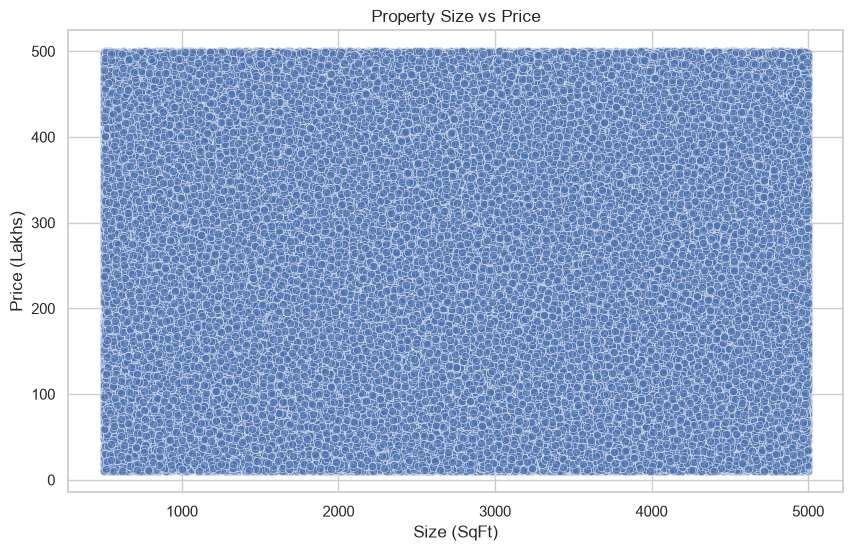

Correlation between Size and Price: -0.0025285467925389073


In [59]:
# ============================================================
# Q4. Is there a relationship between property size and price?
# ============================================================
plt.figure(figsize=(10, 6))

sns.scatterplot(
   data=df,
   x="Size_in_SqFt",
   y="Price_in_Lakhs",
   alpha=0.6
)

plt.title("Property Size vs Price")
plt.xlabel("Size (SqFt)")
plt.ylabel("Price (Lakhs)")
plt.show()

print(
   "Correlation between Size and Price:",
   df["Size_in_SqFt"].corr(df["Price_in_Lakhs"])
)

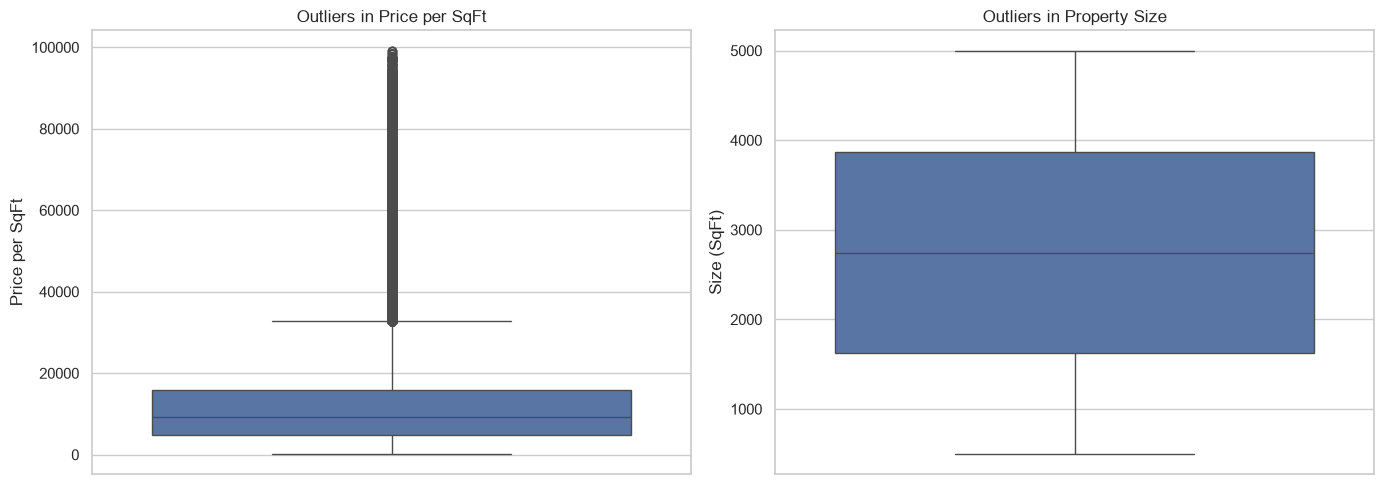

In [60]:
# ============================================================
# Q5. Are there outliers in price per sq ft or property size?
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    y=df["Calculated_Price_per_SqFt"],
    ax=axes[0]
)

axes[0].set_title("Outliers in Price per SqFt")
axes[0].set_ylabel("Price per SqFt")

sns.boxplot(
    y=df["Size_in_SqFt"],
    ax=axes[1]
)

axes[1].set_title("Outliers in Property Size")
axes[1].set_ylabel("Size (SqFt)")

plt.tight_layout()
plt.show()

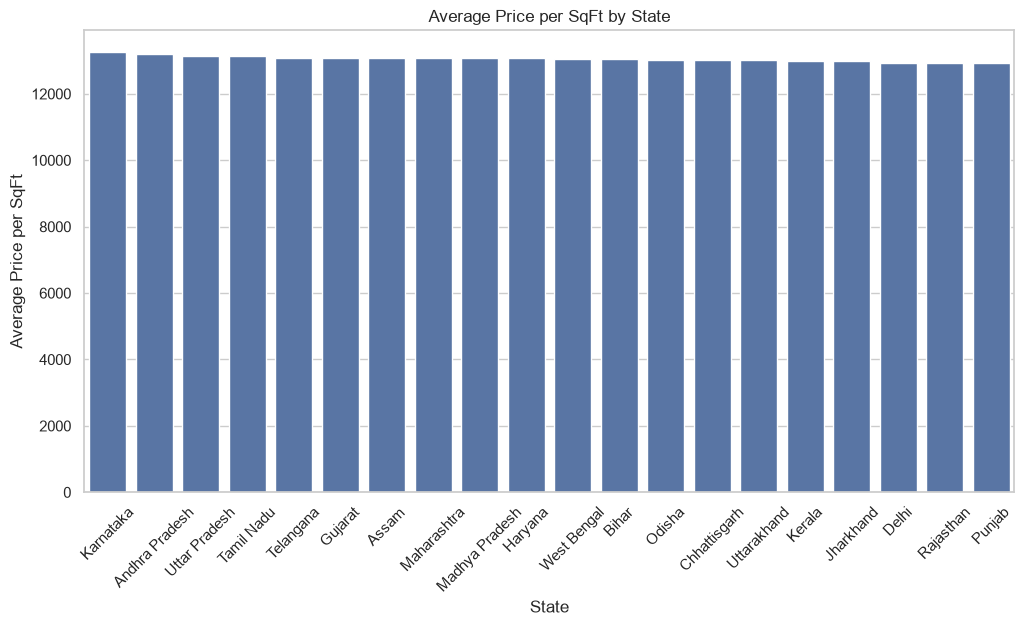

In [61]:
# ============================================================
# Q6. What is the average price per sq ft by state?
# ============================================================
state_price = (
    df.groupby("State")["Calculated_Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(
   x=state_price.index,
   y=state_price.values
)

plt.title("Average Price per SqFt by State")
plt.xlabel("State")
plt.ylabel("Average Price per SqFt")
plt.xticks(rotation=45)
plt.show()

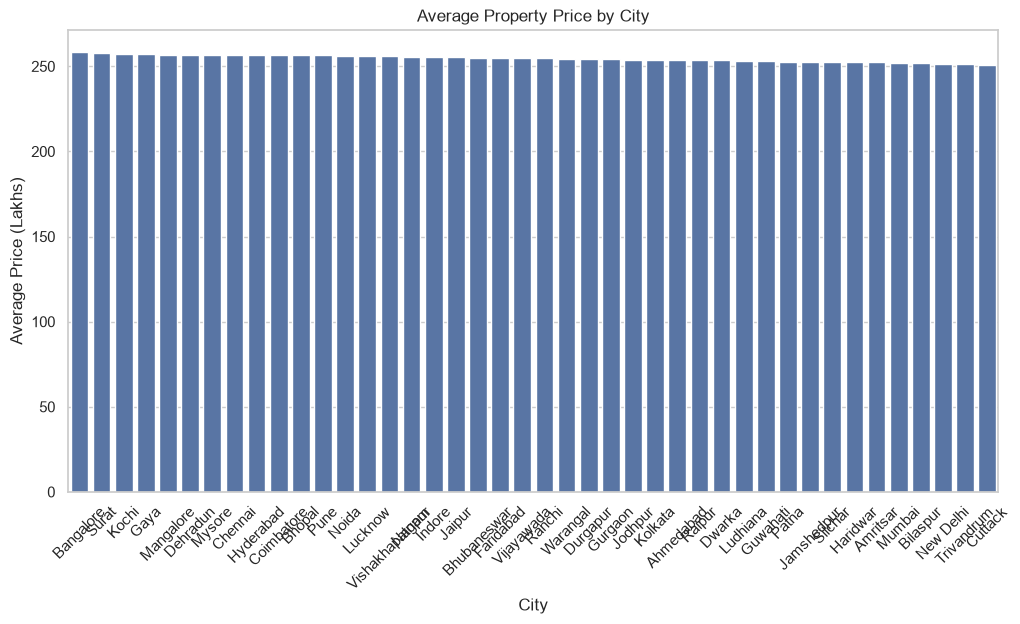

In [62]:
# Q7. What is the average property price by city?
# ============================================================
city_price = (
    df.groupby("City")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=city_price.index,
    y=city_price.values
)

plt.title("Average Property Price by City")
plt.xlabel("City")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=45)
plt.show()


Median Property Age by Locality:
Locality
Locality_72     22.0
Locality_403    22.0
Locality_75     21.0
Locality_127    21.0
Locality_1      21.0
                ... 
Locality_56     18.0
Locality_13     18.0
Locality_63     18.0
Locality_10     18.0
Locality_443    17.0
Name: Calculated_Age_of_Property, Length: 500, dtype: float64


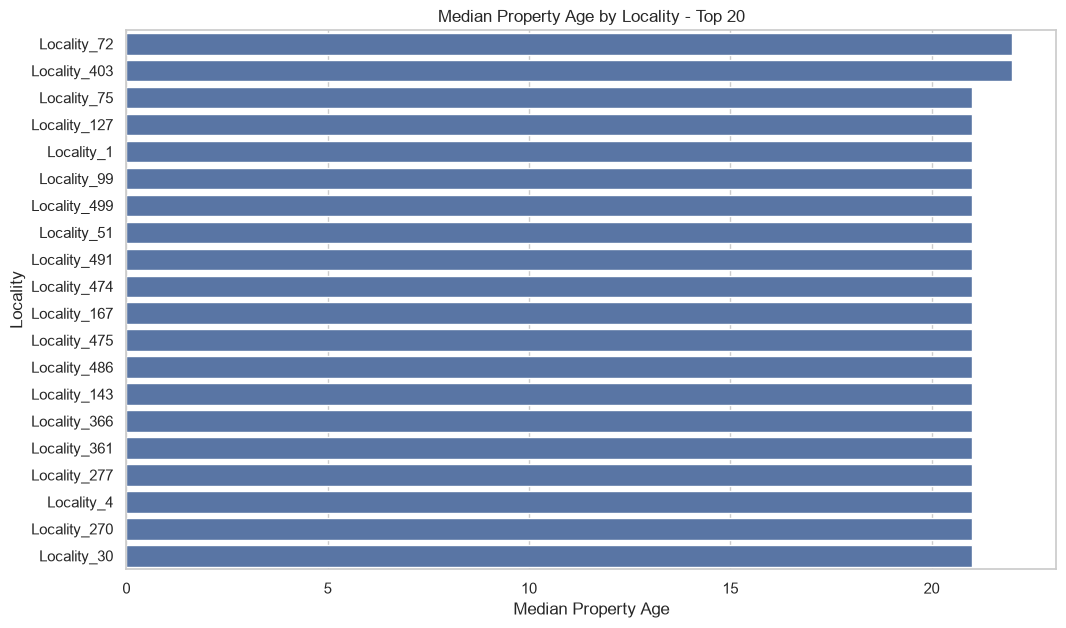

In [63]:
# ============================================================
# Q8. What is the median age of properties by locality?
# ============================================================
locality_age = (
    df.groupby("Locality")["Calculated_Age_of_Property"]
    .median()
    .sort_values(ascending=False)
)

print("\nMedian Property Age by Locality:")
print(locality_age)

# Show top 20 localities
top_locality_age = locality_age.head(20)

plt.figure(figsize=(12, 7))

sns.barplot(
   x=top_locality_age.values,
   y=top_locality_age.index
)

plt.title("Median Property Age by Locality - Top 20")
plt.xlabel("Median Property Age")
plt.ylabel("Locality")
plt.show()

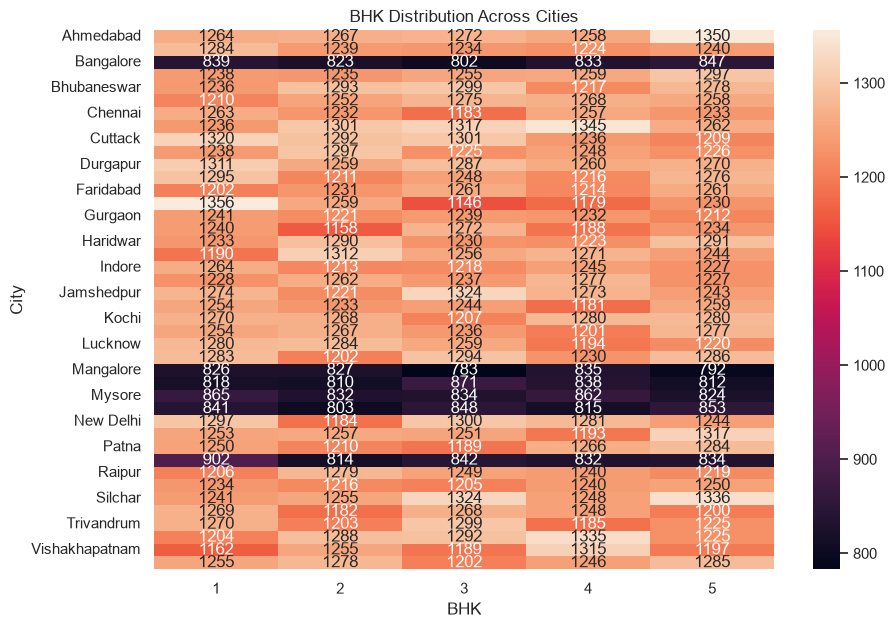

In [66]:
# ============================================================
# Q9. How is BHK distributed across cities?
# ============================================================
bhk_city = pd.crosstab(
    df["City"],
    df["BHK"]
)

plt.figure(figsize=(10, 7))

sns.heatmap(
   bhk_city,
   annot=True,
   fmt="g"
)

plt.title("BHK Distribution Across Cities")
plt.xlabel("BHK")
plt.ylabel("City")
plt.show()

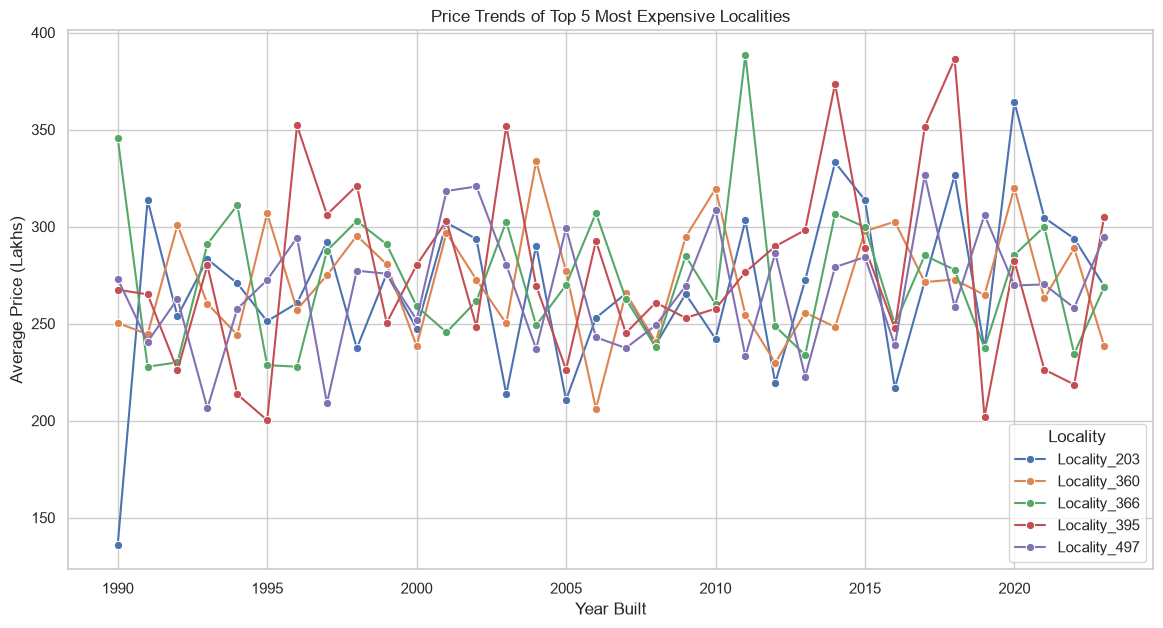

In [67]:
# ============================================================
# Q10. What are the price trends for the top 5 most expensive localities?
# ============================================================
top_5_localities = (
    df.groupby("Locality")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)
top_5_data = df[
    df["Locality"].isin(top_5_localities)
]
trend_data = (
    top_5_data
    .groupby(["Locality", "Year_Built"])["Price_in_Lakhs"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=trend_data,
    x="Year_Built",
    y="Price_in_Lakhs",
    hue="Locality",
    marker="o"
)
plt.title("Price Trends of Top 5 Most Expensive Localities")
plt.xlabel("Year Built")
plt.ylabel("Average Price (Lakhs)")
plt.legend(title="Locality")
plt.show()

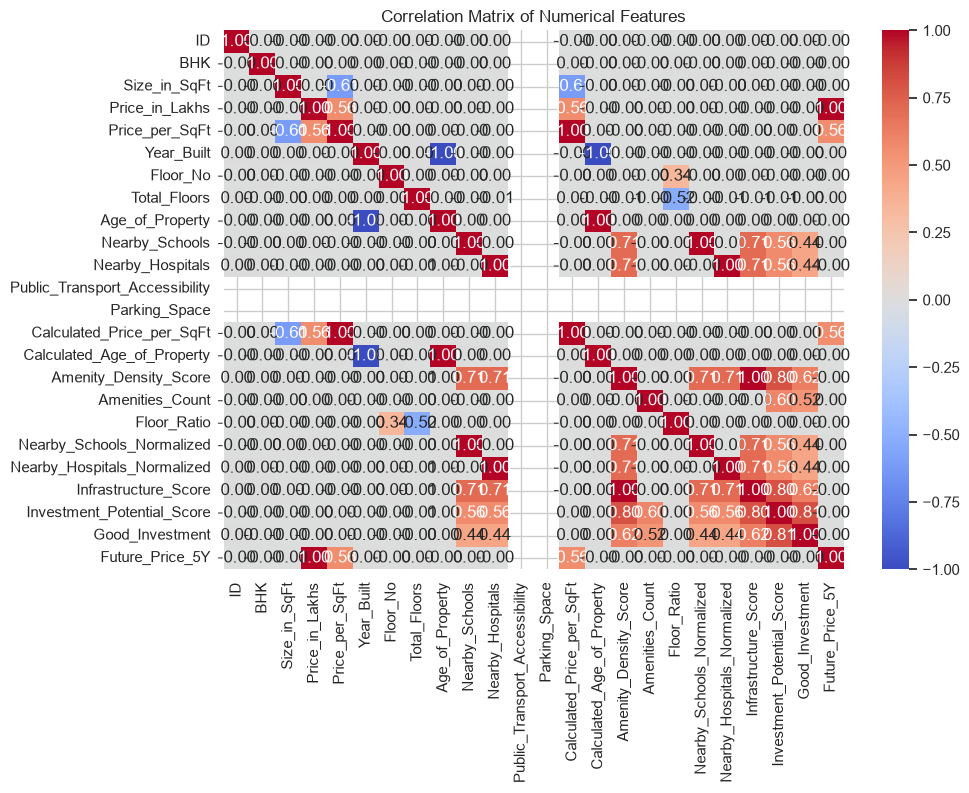

In [69]:
# ============================================================
# Q11. How are numeric features correlated with each other?
# ============================================================
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

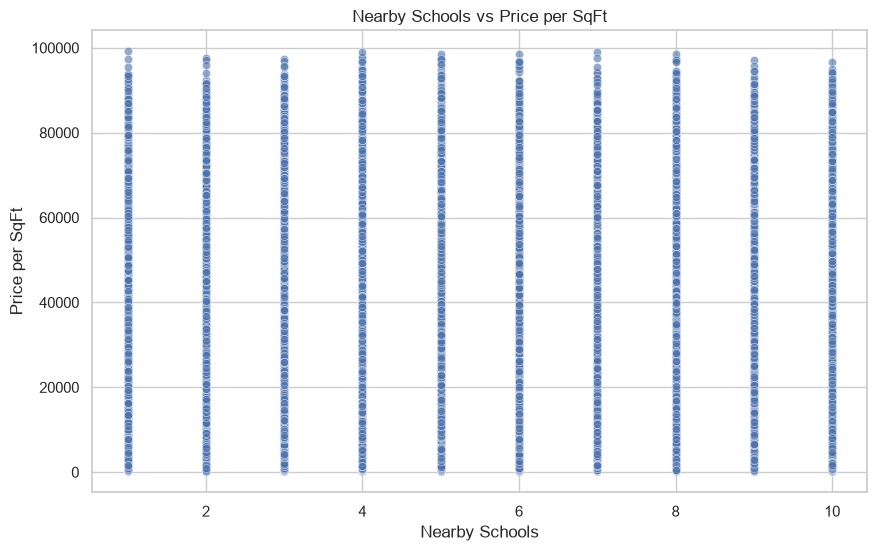

Correlation: -5.823435795966832e-05


In [71]:
# ============================================================
# Q12. How do nearby schools relate to price per sq ft?
# ============================================================
plt.figure(figsize=(10, 6))

sns.scatterplot(
    
     data=df,
     x="Nearby_Schools",
     y="Calculated_Price_per_SqFt",
     alpha=0.6
)

plt.title("Nearby Schools vs Price per SqFt")
plt.xlabel("Nearby Schools")
plt.ylabel("Price per SqFt")
plt.show()

print(
     "Correlation:",
     df["Nearby_Schools"].corr(
         df["Calculated_Price_per_SqFt"]
    )
)

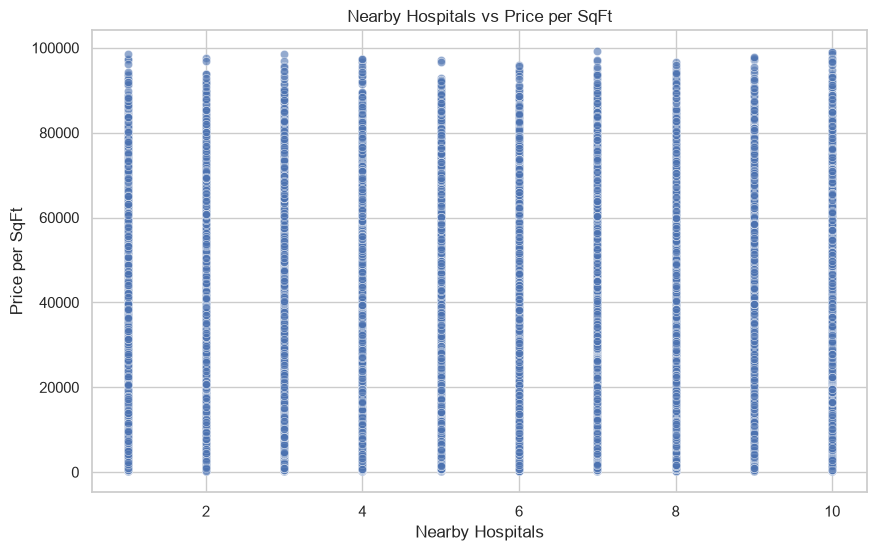

Correlation: -0.00012211712435820747


In [72]:
# ============================================================
# Q13. How do nearby hospitals relate to price per sq ft?
# ============================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    
    data=df,
    x="Nearby_Hospitals",
    y="Calculated_Price_per_SqFt",
    alpha=0.6
)

plt.title("Nearby Hospitals vs Price per SqFt")
plt.xlabel("Nearby Hospitals")
plt.ylabel("Price per SqFt")
plt.show()

print(
    "Correlation:",
    df["Nearby_Hospitals"].corr(
        df["Calculated_Price_per_SqFt"]
    )
)

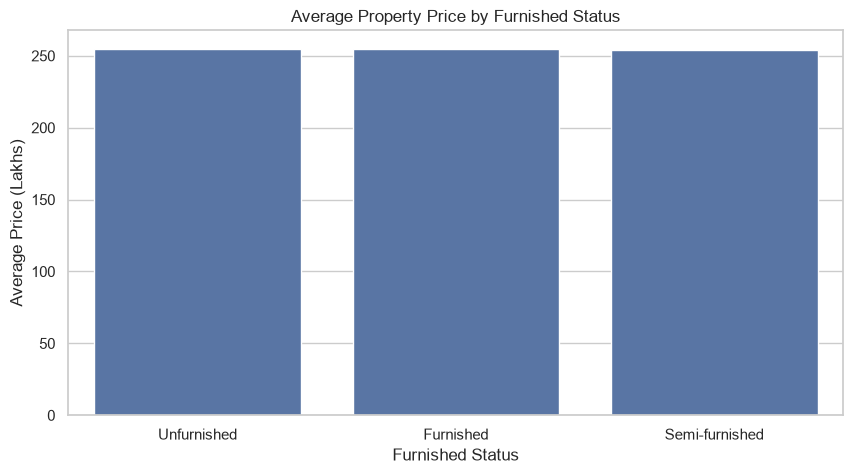

In [73]:
# ============================================================
# Q14. How does price vary by furnished status?
# ============================================================
furnished_price = (
    df.groupby("Furnished_Status")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=furnished_price.index,
    y=furnished_price.values
)

plt.title("Average Property Price by Furnished Status")
plt.xlabel("Furnished Status")
plt.ylabel("Average Price (Lakhs)")
plt.show()

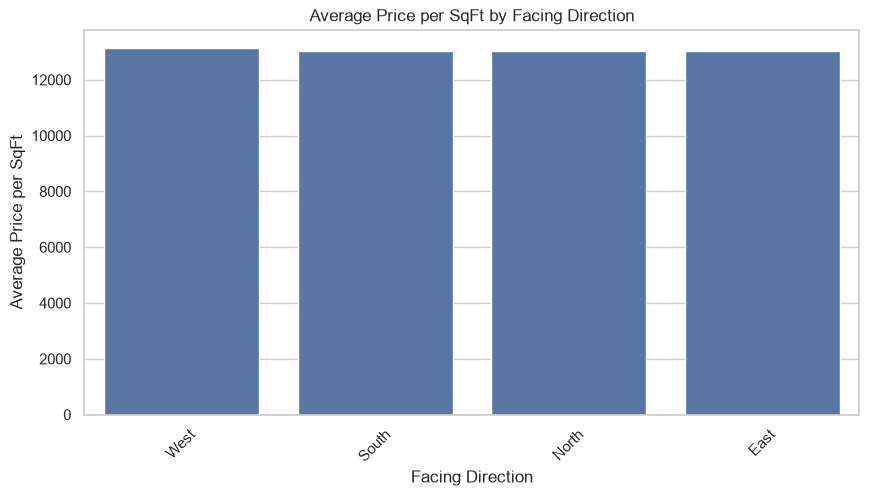

In [74]:
# ============================================================
# Q15. How does price per sq ft vary by property facing?
# ============================================================
facing_price = (
    df.groupby("Facing")["Calculated_Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10, 5))

sns.barplot(
    x=facing_price.index,
    y=facing_price.values
)

plt.title("Average Price per SqFt by Facing Direction")
plt.xlabel("Facing Direction")
plt.ylabel("Average Price per SqFt")
plt.xticks(rotation=45)
plt.show()

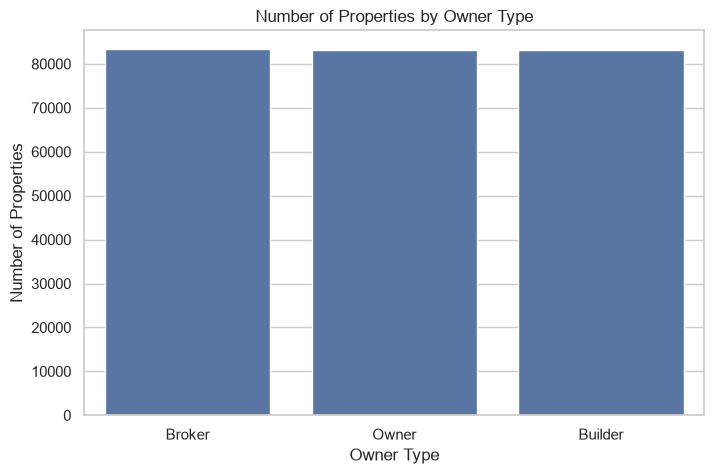

Owner_Type
Broker     83479
Owner      83268
Builder    83253
Name: count, dtype: int64[pyarrow]


In [76]:
# ============================================================
# Q16. How many properties belong to each owner type?
# ============================================================
owner_counts = (
    df["Owner_Type"]
    .value_counts()
)
plt.figure(figsize=(8, 5))
sns.barplot(
    x=owner_counts.index,
    y=owner_counts.values
)

plt.title("Number of Properties by Owner Type")
plt.xlabel("Owner Type")
plt.ylabel("Number of Properties")
plt.show()

print(owner_counts)

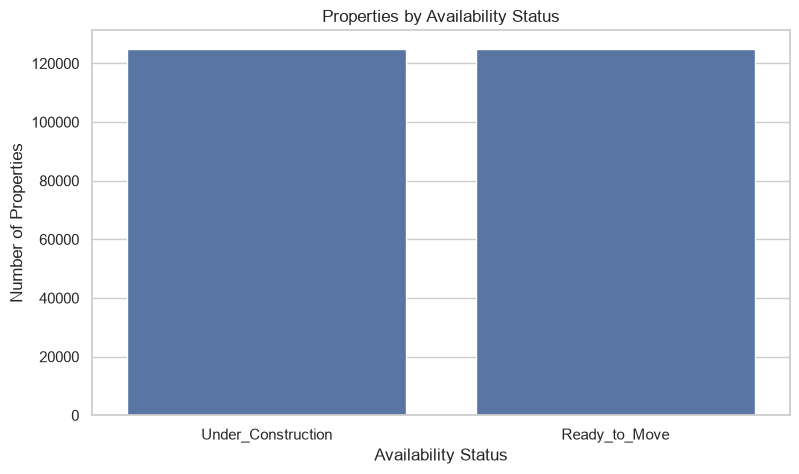

Availability_Status
Under_Construction    125035
Ready_to_Move         124965
Name: count, dtype: int64[pyarrow]


In [77]:
# ============================================================
# Q17. How many properties are available under each availability status?
# ============================================================
availability_counts = (
     df["Availability_Status"]
     .value_counts()
)
plt.figure(figsize=(9, 5))

sns.barplot(
    x=availability_counts.index,
    y=availability_counts.values
)
plt.title("Properties by Availability Status")
plt.xlabel("Availability Status")
plt.ylabel("Number of Properties")
plt.show()
print(availability_counts)

In [82]:
print("Parking_Space datatype:")
print(df["Parking_Space"].dtype)

print("\nUnique values:")
print(df["Parking_Space"].unique())

print("\nValue counts:")
print(df["Parking_Space"].value_counts(dropna=False))

print("\nMissing values:")
print(df["Parking_Space"].isna().sum())

print("\nNumber of unique values:")
print(df["Parking_Space"].nunique(dropna=True))

Parking_Space datatype:
Float64

Unique values:
<FloatingArray>
[0.0]
Length: 1, dtype: Float64

Value counts:
Parking_Space
0.0    250000
Name: count, dtype: Int64

Missing values:
0

Number of unique values:
1


In [83]:
# ============================================================
# Q18. Does parking space affect property price?
# ============================================================

print("Parking Space Distribution:")
print(df["Parking_Space"].value_counts())


# Check variation
if df["Parking_Space"].nunique() <= 1:

    print("\n⚠️ Parking_Space has no variation in the dataset.")
    print("All properties have the same parking value.")
    print("Therefore, correlation with property price cannot be calculated.")

else:

    # Boxplot
    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x="Parking_Space",
        y="Price_in_Lakhs"
    )

    plt.title("Parking Space vs Property Price")
    plt.xlabel("Parking Spaces")
    plt.ylabel("Price (Lakhs)")

    plt.show()

    # Correlation
    correlation = df["Parking_Space"].corr(
        df["Price_in_Lakhs"]
    )

    print(
        "\nCorrelation between Parking and Price:",
        correlation
    )

Parking Space Distribution:
Parking_Space
0.0    250000
Name: count, dtype: Int64

⚠️ Parking_Space has no variation in the dataset.
All properties have the same parking value.
Therefore, correlation with property price cannot be calculated.


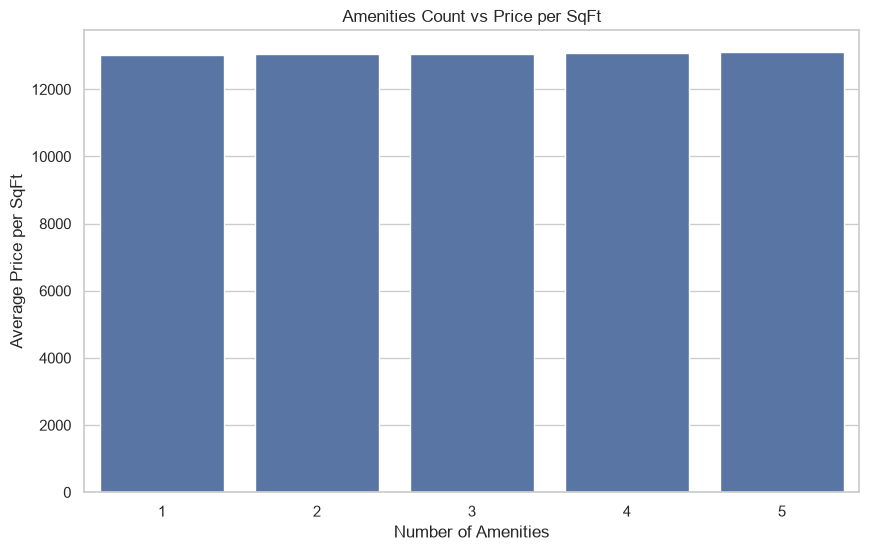

In [84]:
# ============================================================
# Q19. How do amenities affect price per sq ft?
# ============================================================
amenity_price = (
    df.groupby("Amenities_Count")[
        "Calculated_Price_per_SqFt"
    ]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=amenity_price.index,
    y=amenity_price.values
)
plt.title("Amenities Count vs Price per SqFt")
plt.xlabel("Number of Amenities")
plt.ylabel("Average Price per SqFt")
plt.show()

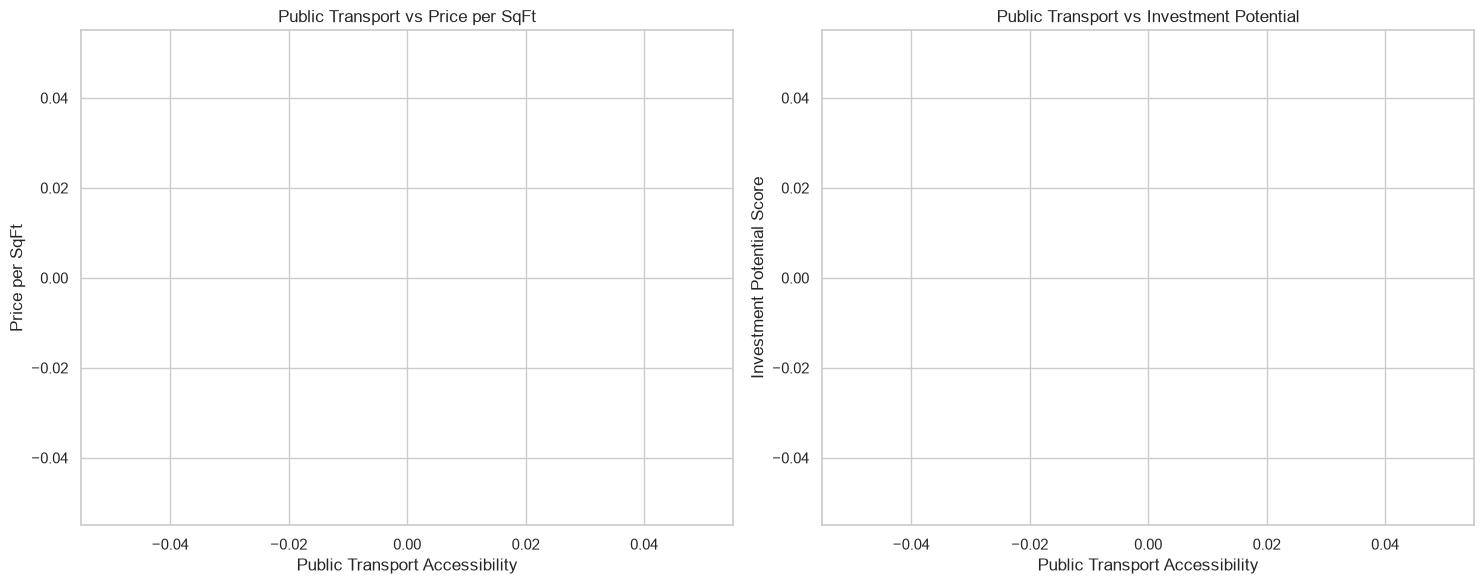

Transport vs Price correlation: nan
Transport vs Investment correlation: nan


In [85]:
# ============================================================
# Q20. How does public transport accessibility relate to price per sq ft or investment potential?
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Transport vs Price
sns.scatterplot(
    data=df,
    x="Public_Transport_Accessibility",
    y="Calculated_Price_per_SqFt",
    ax=axes[0],
    alpha=0.6
)
axes[0].set_title(
    "Public Transport vs Price per SqFt"
)
axes[0].set_xlabel(
    "Public Transport Accessibility"
)
axes[0].set_ylabel(
    "Price per SqFt"
)
# Transport vs Investment
sns.scatterplot(
    data=df,
    x="Public_Transport_Accessibility",
    y="Investment_Potential_Score",
    ax=axes[1],
    alpha=0.6
)
axes[1].set_title(
   "Public Transport vs Investment Potential"
)
axes[1].set_xlabel(
   "Public Transport Accessibility"
)
axes[1].set_ylabel(
   "Investment Potential Score"
)
plt.tight_layout()
plt.show()

print(
    "Transport vs Price correlation:",
    df["Public_Transport_Accessibility"].corr(
        df["Calculated_Price_per_SqFt"]
    )
)
print(
    "Transport vs Investment correlation:",
    df["Public_Transport_Accessibility"].corr(
        df["Investment_Potential_Score"]
    )
)

    